In [94]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [95]:
# Membaca dataset lewat google drive
path = path = "/content/gdrive/MyDrive/Praktikum02/Praktikum12/data/dataa.csv"

In [96]:
# Import library dasar
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # tetap diimport walau kadang tak terpakai

plt.rcParams['figure.figsize'] = (8, 6)

In [97]:
# Cek beberapa baris pertama
df = pd.read_csv(path)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [99]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [100]:
# Cek missing value
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [101]:
# Cek data dulikat
df.duplicated().sum()

np.int64(0)

In [102]:
# Eksplorasi label / target
label_col = "diagnosis"

print("\nDistribusi label:")
print(df[label_col].value_counts())


Distribusi label:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [103]:
# Pemisahan fitur dan label
X = df.drop(columns=[label_col, 'Unnamed: 32'])   # drop 'Unnamed: 32' karena semua isinya NaN
y = df[label_col]

In [104]:
# Encode label (misal B/M) menjadi 0/1 agar cocok untuk model ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)    # jadi 0/1

In [105]:
# Bagi data menjadi train dan test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

Shape X_train: (455, 31)
Shape X_test : (114, 31)


In [106]:
# Standardisasi fitur (mean = 0, std = 1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform di data train
X_test_scaled  = scaler.transform(X_test)       # hanya transform di data test

print("Contoh 3 baris X_train_scaled:")
print(X_train_scaled[:3])

Contoh 3 baris X_train_scaled:
[[-2.43221088e-01  5.18558727e-01  8.91825791e-01  4.24631702e-01
   3.83925436e-01 -9.74743706e-01 -6.89771505e-01 -6.88586446e-01
  -3.98175254e-01 -1.03915470e+00 -8.25056321e-01 -1.09317755e-01
  -5.59755400e-02 -2.10096206e-01 -1.59132582e-02 -1.00518399e+00
  -9.11941990e-01 -6.62815884e-01 -6.52561081e-01 -7.01889114e-01
  -2.75393571e-01  5.79797697e-01  1.31324246e+00  4.66908134e-01
   4.45982711e-01 -5.96154777e-01 -6.34722227e-01 -6.10227299e-01
  -2.35743918e-01  5.45663235e-02  2.18367276e-02]
 [ 4.08373367e-01 -5.16364088e-01 -1.63971029e+00 -5.41348716e-01
  -5.42961327e-01  4.76219058e-01 -6.31833818e-01 -6.04281166e-01
  -3.03074908e-01  5.21543093e-01 -4.54522896e-01 -6.04377961e-01
  -1.00104604e+00 -5.85429002e-01 -4.93453793e-01  4.03212009e-01
  -7.68173276e-01 -4.79187222e-01  1.14508478e-01 -1.42950761e-01
  -5.77397732e-01 -5.82458953e-01 -1.69029101e+00 -6.11934288e-01
  -5.87013537e-01  2.73581959e-01 -8.14844486e-01 -7.1266641

In [107]:
# Model baseline: SVM tanpa PCA

svm_nopca = SVC(kernel="rbf", gamma="scale")
svm_nopca.fit(X_train_scaled, y_train)

y_pred_nopca = svm_nopca.predict(X_test_scaled)

acc_nopca = accuracy_score(y_test, y_pred_nopca)
print("Akurasi SVM tanpa PCA  :", acc_nopca)

print("\nClassification report (tanpa PCA):")
print(classification_report(y_test, y_pred_nopca))

print("Confusion matrix (tanpa PCA):")
print(confusion_matrix(y_test, y_pred_nopca))

Akurasi SVM tanpa PCA  : 0.9649122807017544

Classification report (tanpa PCA):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion matrix (tanpa PCA):
[[71  1]
 [ 3 39]]


In [108]:
# PCA: reduksi dimensi menjadi 3 komponen utama

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_
print("Explained variance ratio per komponen:", explained)
print("Total variansi yang dijelaskan (3 PC):", explained.sum())

Explained variance ratio per komponen: [0.43184634 0.17962517 0.0935514 ]
Total variansi yang dijelaskan (3 PC): 0.7050229101608617


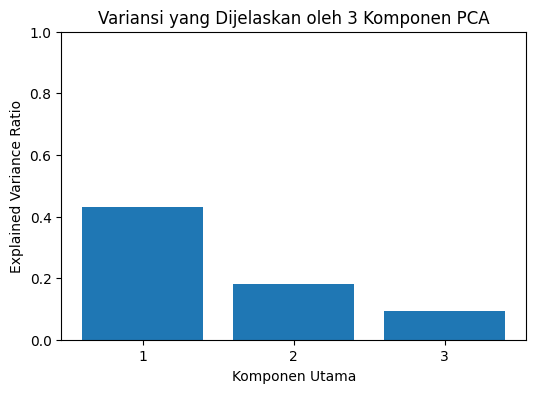

In [109]:
# Visualisasi Explained Variance Ratio (bar chart)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(6, 4))
plt.bar([1, 2, 3], explained_var)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variansi yang Dijelaskan oleh 3 Komponen PCA')
plt.xticks([1, 2, 3])
plt.ylim(0, 1)
plt.show()

In [110]:
# Model SVM dengan fitur hasil PCA

svm_pca = SVC(kernel="rbf", gamma="scale")
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("Akurasi SVM dengan PCA :", acc_pca)

print("\nClassification report (dengan PCA):")
print(classification_report(y_test, y_pred_pca))

print("Confusion matrix (dengan PCA):")
print(confusion_matrix(y_test, y_pred_pca))

Akurasi SVM dengan PCA : 0.956140350877193

Classification report (dengan PCA):
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion matrix (dengan PCA):
[[72  0]
 [ 5 37]]


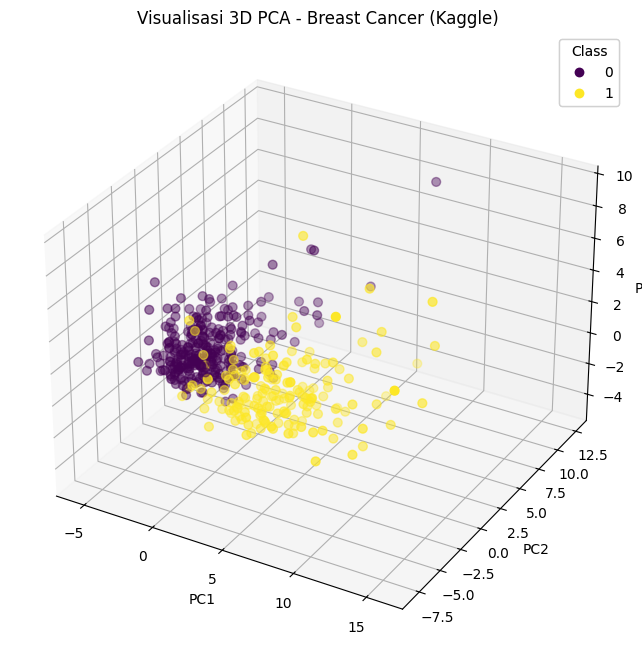

In [111]:
# Visualisasi 3D PCA (PC1, PC2, PC3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    cmap="viridis",
    s=40
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Visualisasi 3D PCA - Breast Cancer (Kaggle)")

legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)

plt.show()

In [112]:
# Ringkasan perbandingan akurasi (untuk bahan interpretasi di laporan)

print("Akurasi SVM tanpa PCA  :", acc_nopca)
print("Akurasi SVM dengan PCA :", acc_pca)
print("Total variansi PCA (3 komponen):", explained.sum())

Akurasi SVM tanpa PCA  : 0.9649122807017544
Akurasi SVM dengan PCA : 0.956140350877193
Total variansi PCA (3 komponen): 0.7050229101608617
